In [1]:
# Импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

In [2]:
# Загрузка и предобработка данных
dt = pd.read_csv('test_d.csv')
print(dt['1. Существенное'].value_counts())
print(dt['1. Направление'].value_counts())
dt = dt.fillna(0)

1. Существенное
0    842
1    158
Name: count, dtype: int64
1. Направление
 1.0    138
-1.0     17
Name: count, dtype: int64


In [3]:
# Функция пайплайна для двухэтапной классификации
def classification_pipeline(
    clf1, clf2, X, y, model_name="Model", test_size=0.2, random_state=42
):
    """
    Двухэтапный пайплайн классификации:
    1. Первый классификатор: 0 vs {1, -1}
    2. Второй классификатор: 1 vs -1 (только среди ненулевых предсказаний)

    Параметры:
    -----------
    clf1 : classifier
        Классификатор первого этапа (0 vs {1, -1})
    clf2 : classifier
        Классификатор второго этапа (1 vs -1)
    X : array-like
        Матрица признаков (может быть текст или уже векторизованные данные)
    y : array-like
        Целевые метки
    model_name : str
        Название комбинации моделей
    test_size : float
        Доля тестовой выборки
    random_state : int
        Random state для воспроизводимости

    Возвращает:
    --------
    tuple : (f1_score_этап1, f1_score_этап2, f1_score_класс_минус1)
    """

    print(f"Запуск пайплайна: {model_name}\n")

    # Разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Этап 1: 0 vs {1, -1}
    print("Этап 1: Классификация 0 vs {1, -1}")

    y_train_bin1 = (y_train != 0).astype(int)
    y_test_bin1 = (y_test != 0).astype(int)

    # Балансировка с помощью SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train_bin1)

    # Обучение первого классификатора
    clf1.fit(X_train_bal, y_train_bal)
    y_pred_bin1 = clf1.predict(X_test)

    # Оценка первого классификатора
    print(classification_report(y_test_bin1, y_pred_bin1, zero_division=0))
    f1_stage1 = float(f1_score(y_test_bin1, y_pred_bin1, average="weighted", zero_division=0))

    # Этап 2: 1 vs -1 (только среди ненулевых)
    print("Этап 2: Классификация 1 vs -1")

    # Создаем маски для фильтрации
    train_mask_series = y_train_bin1 == 1
    train_mask = (
        train_mask_series.values
        if hasattr(train_mask_series, "values")
        else train_mask_series
    )

    test_mask = y_pred_bin1 == 1

    # Фильтруем данные используя numpy boolean indexing
    X_train_bin2 = X_train[train_mask]
    y_train_bin2 = (
        y_train.values[train_mask]
        if hasattr(y_train, "values")
        else y_train[train_mask]
    )

    X_test_bin2 = X_test[test_mask]
    y_test_bin2 = (
        y_test.values[test_mask] if hasattr(y_test, "values") else y_test[test_mask]
    )

    # Используем .shape[0] вместо len() для sparse matrices
    if X_test_bin2.shape[0] == 0:
        print("Предупреждение: На этапе 1 не было предсказано ненулевых образцов!")
        f1_stage2 = 0.0
        f1_minus1 = 0.0
    else:
        # Балансировка с помощью SMOTE для второго этапа
        smote = SMOTE(random_state=random_state)
        X_train_bal2, y_train_bal2 = smote.fit_resample(X_train_bin2, y_train_bin2)

        # Обучение второго классификатора
        clf2.fit(X_train_bal2, y_train_bal2)
        y_pred_bin2 = clf2.predict(X_test_bin2)

        # Оценка второго классификатора
        print(classification_report(y_test_bin2, y_pred_bin2, zero_division=0))
        f1_stage2 = float(f1_score(
            y_test_bin2, y_pred_bin2, average="weighted", zero_division=0
        ))
        
        # F1-score специально для класса -1
        f1_minus1 = float(f1_score(
            y_test_bin2, y_pred_bin2, labels=[-1], average="weighted", zero_division=0
        ))

    print(f"Этап 1 F1: {f1_stage1:.4f}")
    print(f"Этап 2 F1 (общий): {f1_stage2:.4f}")
    print(f"Этап 2 F1 (класс -1): {f1_minus1:.4f}")

    return f1_stage1, f1_stage2, f1_minus1

In [4]:
# Подготовка данных и векторизация текста
X = dt['filtered_text']
y = dt['1. Направление']

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_vectorized = vectorizer.fit_transform(X)

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Запуск пайплайна: Наивный Байес + Случайный Лес
f1_1, f1_2, f1_minus1_1 = classification_pipeline(
    clf1=MultinomialNB(),
    clf2=RandomForestClassifier(class_weight='balanced', random_state=42),
    X=X_vectorized,
    y=y,
    model_name="Наивный Байес + Случайный Лес"
)

Запуск пайплайна: Наивный Байес + Случайный Лес

Этап 1: Классификация 0 vs {1, -1}
              precision    recall  f1-score   support

           0       0.97      0.80      0.87       171
           1       0.42      0.86      0.56        29

    accuracy                           0.81       200
   macro avg       0.69      0.83      0.72       200
weighted avg       0.89      0.81      0.83       200

Этап 2: Классификация 1 vs -1
              precision    recall  f1-score   support

        -1.0       0.50      0.33      0.40         3
         0.0       0.00      0.00      0.00        35
         1.0       0.38      1.00      0.55        22

    accuracy                           0.38        60
   macro avg       0.29      0.44      0.32        60
weighted avg       0.16      0.38      0.22        60

Этап 1 F1: 0.8292
Этап 2 F1 (общий): 0.2217
Этап 2 F1 (класс -1): 0.4000


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# Запуск пайплайна: Случайный Лес + Наивный Байес
f2_1, f2_2, f2_minus1_1 = classification_pipeline(
    clf1=RandomForestClassifier(class_weight='balanced', random_state=42),
    clf2=MultinomialNB(),
    X=X_vectorized,
    y=y,
    model_name="Случайный Лес + Наивный Байес"
)

Запуск пайплайна: Случайный Лес + Наивный Байес

Этап 1: Классификация 0 vs {1, -1}
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
           1       0.83      0.69      0.75        29

    accuracy                           0.94       200
   macro avg       0.89      0.83      0.86       200
weighted avg       0.93      0.94      0.93       200

Этап 2: Классификация 1 vs -1
              precision    recall  f1-score   support

        -1.0       0.25      1.00      0.40         2
         0.0       0.00      0.00      0.00         4
         1.0       0.81      0.72      0.76        18

    accuracy                           0.62        24
   macro avg       0.35      0.57      0.39        24
weighted avg       0.63      0.62      0.61        24

Этап 1 F1: 0.9324
Этап 2 F1 (общий): 0.6069
Этап 2 F1 (класс -1): 0.4000
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Запуск пайплайна: Случайный Лес + Случайный Лес
f3_1, f3_2, f3_minus1_1 = classification_pipeline(
    clf1=RandomForestClassifier(class_weight='balanced', random_state=42),
    clf2=RandomForestClassifier(class_weight='balanced', random_state=42),
    X=X_vectorized,
    y=y,
    model_name="Случайный Лес + Случайный Лес"
)

Запуск пайплайна: Случайный Лес + Случайный Лес

Этап 1: Классификация 0 vs {1, -1}
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
           1       0.83      0.69      0.75        29

    accuracy                           0.94       200
   macro avg       0.89      0.83      0.86       200
weighted avg       0.93      0.94      0.93       200

Этап 2: Классификация 1 vs -1
              precision    recall  f1-score   support

        -1.0       1.00      0.50      0.67         2
         0.0       0.00      0.00      0.00         4
         1.0       0.78      1.00      0.88        18

    accuracy                           0.79        24
   macro avg       0.59      0.50      0.51        24
weighted avg       0.67      0.79      0.71        24

Этап 1 F1: 0.9324
Этап 2 F1 (общий): 0.7141
Этап 2 F1 (класс -1): 0.6667
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Запуск пайплайна: Случайный Лес + SVM
f4_1, f4_2, f4_minus1_1 = classification_pipeline(
    clf1=RandomForestClassifier(class_weight='balanced', random_state=42),
    clf2=SVC(),
    X=X_vectorized,
    y=y,
    model_name="Случайный Лес + SVM"
)

Запуск пайплайна: Случайный Лес + SVM

Этап 1: Классификация 0 vs {1, -1}
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
           1       0.83      0.69      0.75        29

    accuracy                           0.94       200
   macro avg       0.89      0.83      0.86       200
weighted avg       0.93      0.94      0.93       200

Этап 2: Классификация 1 vs -1
              precision    recall  f1-score   support

        -1.0       0.33      0.50      0.40         2
         0.0       0.00      0.00      0.00         4
         1.0       0.81      0.94      0.87        18

    accuracy                           0.75        24
   macro avg       0.38      0.48      0.42        24
weighted avg       0.63      0.75      0.69        24

Этап 1 F1: 0.9324
Этап 2 F1 (общий): 0.6872
Этап 2 F1 (класс -1): 0.4000
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
      

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Запуск пайплайна: Случайный Лес + Дерево Решений
f5_1, f5_2, f5_minus1_1 = classification_pipeline(
    clf1=RandomForestClassifier(class_weight='balanced', random_state=42),
    clf2=DecisionTreeClassifier(),
    X=X_vectorized,
    y=y,
    model_name="Случайный Лес + Дерево Решений"
)

Запуск пайплайна: Случайный Лес + Дерево Решений

Этап 1: Классификация 0 vs {1, -1}
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
           1       0.83      0.69      0.75        29

    accuracy                           0.94       200
   macro avg       0.89      0.83      0.86       200
weighted avg       0.93      0.94      0.93       200

Этап 2: Классификация 1 vs -1
              precision    recall  f1-score   support

        -1.0       0.33      0.50      0.40         2
         0.0       0.00      0.00      0.00         4
         1.0       0.86      1.00      0.92        18

    accuracy                           0.79        24
   macro avg       0.40      0.50      0.44        24
weighted avg       0.67      0.79      0.73        24

Этап 1 F1: 0.9324
Этап 2 F1 (общий): 0.7256
Этап 2 F1 (класс -1): 0.4000
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      

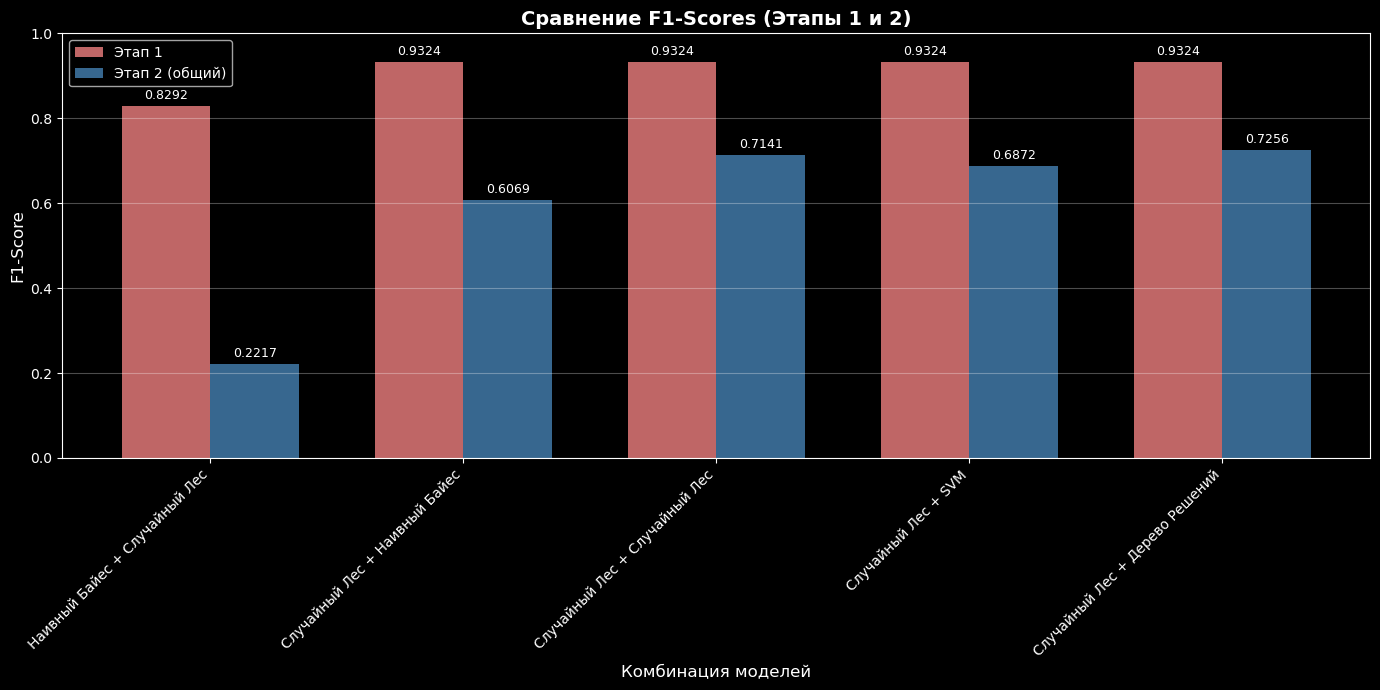

In [10]:
# Визуализация F1-scores для всех этапов
models = [
    'Наивный Байес + Случайный Лес',
    'Случайный Лес + Наивный Байес',
    'Случайный Лес + Случайный Лес',
    'Случайный Лес + SVM',
    'Случайный Лес + Дерево Решений'
]
f1_scores_1 = [f1_1, f2_1, f3_1, f4_1, f5_1]
f1_scores_2 = [f1_2, f2_2, f3_2, f4_2, f5_2]
f1_scores_minus1 = [f1_minus1_1, f2_minus1_1, f3_minus1_1, f4_minus1_1, f5_minus1_1]

# Настройка для размещения баров рядом
x = np.arange(len(models))  # позиции меток
width = 0.35  # ширина баров

plt.figure(figsize=(14, 7))
bars1 = plt.bar(x - width/2, f1_scores_1, width, label='Этап 1', color='lightcoral', alpha=0.8)
bars2 = plt.bar(x + width/2, f1_scores_2, width, label='Этап 2 (общий)', color='steelblue', alpha=0.8)

plt.xlabel("Комбинация моделей", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.title("Сравнение F1-Scores (Этапы 1 и 2)", fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


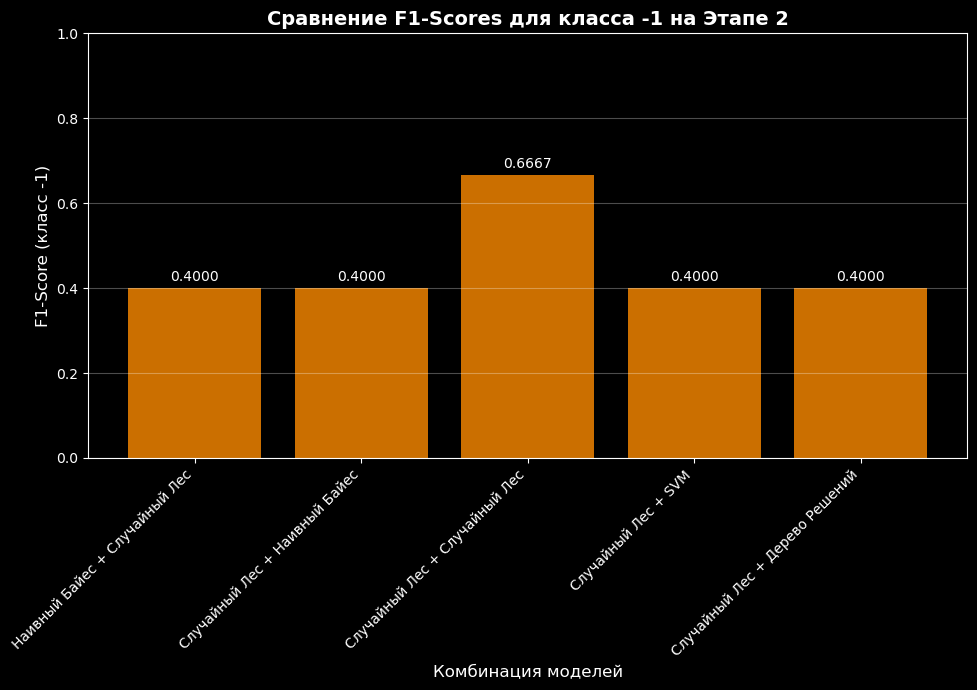

In [11]:
# Визуализация F1-scores для класса -1
plt.figure(figsize=(10, 7))
bars = plt.bar(models, f1_scores_minus1, color='darkorange', alpha=0.8)

plt.xlabel("Комбинация моделей", fontsize=12)
plt.ylabel("F1-Score (класс -1)", fontsize=12)
plt.title("Сравнение F1-Scores для класса -1 на Этапе 2", fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [15]:
# Сводка всех результатов
results_df = pd.DataFrame({
    'Комбинация моделей': models,
    'Этап 1 F1': f1_scores_1,
    'Этап 2 F1': f1_scores_2,
    'Этап 2 F1 (класс -1)': f1_scores_minus1,
})

# Округление до 4 знаков после запятой
results_df = results_df.round(4)

# Поиск лучшей модели
best_stage2_idx = np.argmax(f1_scores_2)
best_minus1_idx = np.argmax(f1_scores_minus1)
print(f"\nЛучшая модель для Этапа 2 (общий): {models[best_stage2_idx]} (F1: {f1_scores_2[best_stage2_idx]:.4f})")
print(f"Лучшая модель для класса -1: {models[best_minus1_idx]} (F1: {f1_scores_minus1[best_minus1_idx]:.4f})")

results_df.to_string()



Лучшая модель для Этапа 2 (общий): Случайный Лес + Дерево Решений (F1: 0.7256)
Лучшая модель для класса -1: Случайный Лес + Случайный Лес (F1: 0.6667)


'               Комбинация моделей  Этап 1 F1  Этап 2 F1  Этап 2 F1 (класс -1)\n0   Наивный Байес + Случайный Лес     0.8292     0.2217                0.4000\n1   Случайный Лес + Наивный Байес     0.9324     0.6069                0.4000\n2   Случайный Лес + Случайный Лес     0.9324     0.7141                0.6667\n3             Случайный Лес + SVM     0.9324     0.6872                0.4000\n4  Случайный Лес + Дерево Решений     0.9324     0.7256                0.4000'